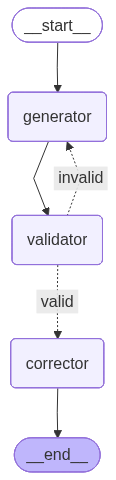

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from node1.node_1 import node_1_generator
from node2.node_2 import node_2_validator
from node3.node_3 import node_3_corrector

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

class DiagramState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    user_input: str
    generated_json: str
    is_valid : bool
    validated_json: str
    corrected_json: str


# build graph
graph = StateGraph(DiagramState)

graph.add_node("generator", node_1_generator)
graph.add_node("validator", node_2_validator)
graph.add_node("corrector", node_3_corrector)

# connect nodes
graph.set_entry_point("generator")
graph.add_edge("generator", "validator")
graph.add_conditional_edges("validator",
    lambda state: "valid" if state.get("is_valid") else "invalid",
    {
        "valid": "corrector",
        "invalid": "generator",
    },)
graph.add_edge("corrector", END)

app = graph.compile()

# initial_state = DiagramState(user_input="Draw me a network diagram")
# final_state = app.invoke(initial_state)

# print(final_state)

from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("error" , e)
    # This requires some extra dependencies and is optional
    pass